In [ ]:
import gymnasium as gym
import liberogymwrapper
import numpy as np
from tqdm import tqdm

In [ ]:
import matplotlib.pyplot as plt
import cv2

def display_image(image, depth=False, colormap=cv2.COLORMAP_JET):
    """
    显示图像
    
    参数:
        image: 输入图像
        depth: 是否为深度图，默认False
        colormap: 深度图的伪彩色映射，默认COLORMAP_JET
    """
    if depth:
        # 深度图处理
        # 归一化到 0-255
        depth_normalized = cv2.normalize(image, None, 0, 255, cv2.NORM_MINMAX)
        depth_uint8 = depth_normalized.astype(np.uint8)
        
        # 应用伪彩色
        depth_colored = cv2.applyColorMap(depth_uint8, colormap)
        
        # BGR -> RGB (OpenCV 输出是 BGR)
        depth_colored = cv2.cvtColor(depth_colored, cv2.COLOR_BGR2RGB)
        
        plt.imshow(depth_colored)
    elif image.ndim == 2:
        # 灰度图，直接显示
        plt.imshow(image, cmap='gray')
    elif image.ndim == 3 and image.shape[2] in [3, 4]:
        # 彩色图
        plt.imshow(image)
    else:
        raise ValueError("输入的图像格式不正确")

    plt.axis('off')
    plt.show()

In [3]:
import torch

_original_torch_load = torch.load

def patched_torch_load(*args, **kwargs):
    # 如果没有明确指定 weights_only，就设为 False
    if 'weights_only' not in kwargs:
        kwargs['weights_only'] = False
    return _original_torch_load(*args, **kwargs)

torch.load = patched_torch_load

In [4]:
env = gym.make(
    "libero-90-v0",             # Task suite name
    task_id             = 0,        # The ID of the task to load (0-9)
    image_size_height   = 224,     # Image resolution (H and W)
    image_size_width    = 224,
    require_point_cloud = False,     # Whether to include point cloud data
    pointcloud_process_device = "cuda:0",  # Device for point cloud processing
    camera_names=["agentview", "robot0_eye_in_hand"],  # A list of cameras to use
    seed=0,
)

[robosuite WARNING] No private macro file found! (__init__.py:7)
[robosuite WARNING] It is recommended to use a private macro file (__init__.py:8)
[robosuite WARNING] To setup, run: python /opt/miniforge3/envs/libero_wrapper/lib/python3.12/site-packages/robosuite/scripts/setup_macros.py (__init__.py:9)


In [5]:
obs, info = env.reset()
for _ in range(5): 
    obs, reward, terminated, truncated, info = env.step([0.0]*7)

In [6]:
obs["robot0_joint_pos"]

array([ 3.24877339e-02, -1.64442140e-01,  9.37489377e-05, -2.43353327e+00,
        3.84621290e-03,  2.22330395e+00,  8.07780579e-01])

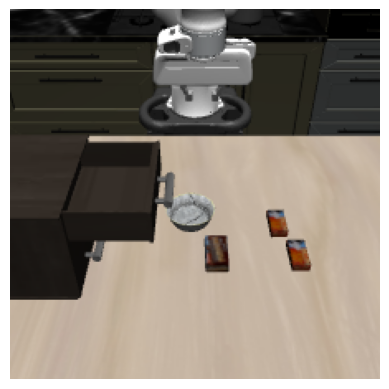

In [7]:
display_image(obs["agentview_image"].transpose(1, 2, 0))

In [12]:
obs, _, _, _, _ = env.step(np.array([-0.6588794 ,  0.7854346 , -0.48034656,  0.0050993 ,  0.04032949, 0.01155512, -0.9905531 ]))
obs["robot0_eef_pos"]

array([-0.22802811,  0.04798289,  1.16271874])

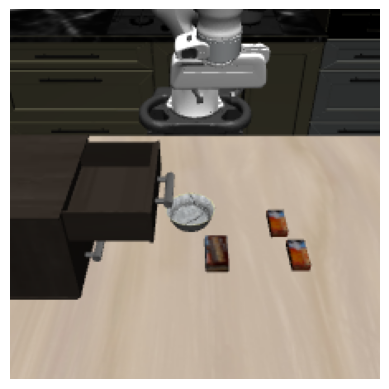

In [13]:
display_image(obs["agentview_image"].transpose(1, 2, 0))

In [74]:
for _ in range(50):
    obs, r, terminated, truncated, i = env.step(np.array([-0.6588794 ,  0.7854346 , -0.48034656,  0.0050993 ,  0.04032949, 0.01155512, -0.9905531 ]))
    
    print("robot0_joint_pos:", obs["robot0_joint_pos"])
    print("robot0_joint_vel:", obs["robot0_joint_vel"])
    print("robot0_eef_pos:", obs["robot0_eef_pos"])
    print("robot0_eef_quat:", obs["robot0_eef_quat"])
    print("robot0_gripper_qpos:", obs["robot0_gripper_qpos"])

    print("")

robot0_joint_pos: [ 0.01936543 -0.14693133  0.01493085 -2.43331601  0.00587377  2.2143768
  0.80459976]
robot0_joint_vel: [ 0.05541409 -0.05893453  0.24904153 -0.24966598  0.1609536  -0.06455371
  0.11876085]
robot0_eef_pos: [-0.20764086  0.01562846  1.17086297]
robot0_eef_quat: [ 9.99343773e-01  5.74342053e-03 -3.57632051e-02 -1.74725912e-04]
robot0_gripper_qpos: [ 0.02102445 -0.02088672]

robot0_joint_pos: [ 0.02280507 -0.15070707  0.02984438 -2.44818183  0.01411709  2.21279268
  0.81352359]
robot0_joint_vel: [ 0.07394081 -0.08886169  0.32036714 -0.32343238  0.15269805  0.01504745
  0.22742534]
robot0_eef_pos: [-0.21400867  0.02418285  1.16628281]
robot0_eef_quat: [ 0.99907739  0.0077088  -0.04222186 -0.00150438]
robot0_gripper_qpos: [ 0.02301554 -0.02275216]

robot0_joint_pos: [ 0.02688631 -0.15563513  0.04717651 -2.46604969  0.02215696  2.2149127
  0.82638028]
robot0_joint_vel: [ 0.08313157 -0.10628153  0.35300879 -0.37299993  0.15491124  0.0822309
  0.27961234]
robot0_eef_pos: [-0

In [77]:
env.env

<OrderEnforcing<PassiveEnvChecker<Libero90Env<libero-90-v0>>>>

In [76]:
robot = env.env.robots[0]

AttributeError: 'OrderEnforcing' object has no attribute 'robots'

In [83]:
robot = env.unwrapped.env.robots[0]
robot.print_action_info()

AttributeError: 'SingleArm' object has no attribute 'print_action_info'

In [84]:
rs_env = env.unwrapped.env
robot = rs_env.robots[0]

# 先看看有哪些“controller”相关字段
print([n for n in dir(robot) if "controller" in n.lower()])

# 尝试抓 controller 对象
ctrl = None
for name in ["part_controllers", "controllers", "controller", "_controller", "arm_controller", "_arm_controller"]:
    if hasattr(robot, name):
        ctrl = getattr(robot, name)
        print("found", name, "type =", type(ctrl))
        break

# 如果是 dict（常见：按手臂名存）
if isinstance(ctrl, dict):
    ctrl = list(ctrl.values())[0]
    print("use first controller in dict ->", type(ctrl))

# 打印你关心的缩放信息
for k in ["control_delta", "input_min", "input_max", "output_min", "output_max"]:
    if hasattr(ctrl, k):
        print(k, getattr(ctrl, k))


['_load_controller', 'controller', 'controller_config']
found controller type = <class 'robosuite.controllers.osc.OperationalSpaceController'>
input_min [-1. -1. -1. -1. -1. -1.]
input_max [1. 1. 1. 1. 1. 1.]
output_min [-0.05 -0.05 -0.05 -0.5  -0.5  -0.5 ]
output_max [0.05 0.05 0.05 0.5  0.5  0.5 ]


In [90]:
action = np.array([
    -0.16472,  0.19636, -0.12009,
     0.001275, 0.010082, 0.002889,
     0.0,      # gripper: 先固定不动；需要打开就改成 -0.99
], dtype=np.float32)

In [91]:
obs, info = env.reset()
for _ in range(5): 
    obs, reward, terminated, truncated, info = env.step([0.0]*7)

In [92]:
for _ in range(50):
    obs, r, terminated, truncated, i = env.step(action)
    for _ in range(20):
        env.step(np.zeros(7))
        obs, r, terminated, truncated, i = env.step(action)
    
    print("robot0_joint_pos:", obs["robot0_joint_pos"])
    print("robot0_joint_vel:", obs["robot0_joint_vel"])
    print("robot0_eef_pos:", obs["robot0_eef_pos"])
    print("robot0_eef_quat:", obs["robot0_eef_quat"])
    print("robot0_gripper_qpos:", obs["robot0_gripper_qpos"])

    print("")

robot0_joint_pos: [ 0.03019573 -0.21568105  0.09770588 -2.54519177  0.04841754  2.2218232
  0.855296  ]
robot0_joint_vel: [ 0.02416897 -0.00863478  0.07444668 -0.06502671  0.05094208  0.00287664
  0.03838647]
robot0_eef_pos: [-0.24961154  0.05514989  1.15487459]
robot0_eef_quat: [ 0.99843503  0.0117982  -0.05459908 -0.00269081]
robot0_gripper_qpos: [ 0.02012031 -0.02010378]

robot0_joint_pos: [ 0.06641245 -0.22124637  0.20635582 -2.63069939  0.11924205  2.2498304
  0.9222955 ]
robot0_joint_vel: [ 0.02930687  0.01352633  0.08622542 -0.04750266  0.0669958   0.0161054
  0.03840046]
robot0_eef_pos: [-0.29170358  0.10808843  1.12441105]
robot0_eef_quat: [ 0.99625525  0.02253865 -0.08337127 -0.00408921]
robot0_gripper_qpos: [ 0.02003234 -0.02000481]

robot0_joint_pos: [ 0.10782258 -0.19176446  0.33032862 -2.68751708  0.20904683  2.29293551
  0.98991042]
robot0_joint_vel: [ 0.03125981  0.04252912  0.0971017  -0.02596633  0.07480328  0.0334153
  0.04026181]
robot0_eef_pos: [-0.33457379  0.1614

ValueError: executing action in terminated episode

In [93]:
action = np.array([
    -0.16472,  0.19636, -0.12009,
     0.001275, 0.010082, 0.002889,
     0.0
], dtype=np.float32)

obs, info = env.reset()
for _ in range(5):
    obs, *_ = env.step(np.zeros(7))

for k in range(50):
    # 1) 只打一枪
    obs, *_ = env.step(action)
    p_after = obs["robot0_eef_pos"].copy()
    q_after = obs["robot0_eef_quat"].copy()

    # 2) 然后只发 0，让它收敛
    for t in range(40):  # 40 可以先随便取个大点
        obs, *_ = env.step(np.zeros(7))

    p_final = obs["robot0_eef_pos"].copy()
    v_norm = np.linalg.norm(obs["robot0_joint_vel"])

    print(k, "p_pulse=", p_after, "p_final=", p_final, "||qdot||=", v_norm)


0 p_pulse= [-0.20691069  0.01665895  1.16504221] p_final= [-0.20881844  0.01851583  1.16361139] ||qdot||= 0.00014409209609154457
1 p_pulse= [-0.20968432  0.01959407  1.16296771] p_final= [-0.21078448  0.02092879  1.16213487] ||qdot||= 9.718552024782351e-05
2 p_pulse= [-0.21165099  0.02200767  1.16149012] p_final= [-0.21275253  0.02334338  1.16065468] ||qdot||= 9.80600909198565e-05
3 p_pulse= [-0.21361973  0.02442313  1.16000882] p_final= [-0.21472267  0.02575973  1.15917076] ||qdot||= 9.885801052804543e-05
4 p_pulse= [-0.21559058  0.02684032  1.15852379] p_final= [-0.21669492  0.02817773  1.15768308] ||qdot||= 9.970622861426354e-05
5 p_pulse= [-0.21756387  0.02925914  1.15703535] p_final= [-0.21867066  0.03059725  1.15619138] ||qdot||= 0.0001005855390082785
6 p_pulse= [-0.21954114  0.03167941  1.15554345] p_final= [-0.22065219  0.03301806  1.15469522] ||qdot||= 0.00010149977223667828
7 p_pulse= [-0.2215244   0.03410094  1.15404736] p_final= [-0.22264082  0.03543997  1.15319434] ||qdot|

ValueError: executing action in terminated episode

In [94]:
print(env.env.env.control_freq)        # 常见
print(env.env.env.control_timestep)    # 常见：应≈0.05

AttributeError: 'PassiveEnvChecker' object has no attribute 'control_freq'

In [97]:
env.unwrapped.env.env.control_freq

20